The objective of this notebook is to define points of error on slope in multidimentional field of parameters such as slope, LOD and number of sampled particles. This would allow us to estimate error on slope one it is found using cumulative sum. For cumulative sum we use $step=step*2$ pattern.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import linregress
from sklearn.metrics import r2_score
from tqdm import tqdm
import seaborn as sns
from matplotlib.colors import ListedColormap, BoundaryNorm


In [3]:
def sample_power_law(xmin_spl, xmax_spl, b_spl, distribution_spl):
    """Samples particle sizes following a power-law distribution."""
    exponent = b_spl + 1
    norm = xmax_spl**exponent - xmin_spl**exponent
    MP_size = (distribution_spl * norm + xmin_spl**exponent) ** (1 / exponent)
    return MP_size
    

In [4]:
def simulated_sampling(xmin_ss, xmax_ss, LOD_min_ss, LOD_max_ss, b_ss, samples_ss):
    """Sample particles from power-law distribution within LOD bounds."""
    part_sampled = sample_power_law(LOD_min_ss, LOD_max_ss, b_ss, samples_ss) # if we dont have N
    if len(part_sampled)==0: print('Problem: There is not enough particles in the LOD range')
    return np.sort(part_sampled) 
    

In [5]:
# Binning and cumulative sum
def cumulative_sum(bins_cs, samplings_cs):
    """Return cumulative sum for each sampling over the bins."""
    lower_bin_limits = bins_cs
    cumulative_counts_all_samplings = []
    for i in range(len(samplings_cs)):
        cumulative_counts = np.array([(samplings_cs[i] >= limit).sum() for limit in lower_bin_limits])
        cumulative_counts_all_samplings.append(cumulative_counts)
    return cumulative_counts_all_samplings
    

The following bin thresholds were determined by observations. This choice may induce errors since the number of useful bins may be bigger but this error would  be compensated within the multiple sampling campaigns.


In [6]:
def determine_bin_threshold(n_sample, LOD_min, slope_th):
    
    """
    Function used for error evaluation exculsively.
    Customed rules to define threshold based on observed cases.
    Threshold can be modified if not coherent with input parameters.
    """
    
    # Custom cases based on updated user rules

    if slope_th < -2.0 and LOD_min > 20.0 and n_sample < 100:
        threshold = 4
        return 0, threshold
    if slope_th == -3.4 and LOD_min == 5 and n_sample > 1000:
        threshold = 7
        return 1, threshold
        
    if LOD_min > 50 and 250 < n_sample < 1000:
        threshold = 5
        return 2, threshold
        
    if slope_th > -2 and LOD_min > 50:
        threshold = 9
        return 3, threshold
        
    if slope_th > -1.4:
        threshold = 5
        return 4, threshold

    # Base cases
    if n_sample <= 50:
        if LOD_min > 130:
            threshold = 9
            return 5, threshold
            
        elif slope_th <= -2:
            threshold = 5
            return 6, threshold
        else:
            threshold = 5
            return 7, threshold
            
    elif n_sample >= 1000:
        if LOD_min > 130:
            threshold = 9
            return 8, threshold
            
        else:
            threshold = 8
            return 9, threshold
            
    else:
        threshold = 4
        return 10, threshold

In [7]:
def plot_threshold_diagnostic(lower_bins, cumulative_counts, minimal_bins_used, slope, intercept):
    """Plot diagnostic showing bins used vs. removed."""
    plt.figure(figsize=(6, 4))
    plt.loglog(lower_bins, cumulative_counts, 'ko-', label='All bins')
    plt.loglog(lower_bins[:minimal_bins_used], cumulative_counts[:minimal_bins_used], 'go-', label='Kept bins')
    plt.loglog(lower_bins[minimal_bins_used:], cumulative_counts[minimal_bins_used:], 'ro-', label='Dropped bins')
    x_fit = lower_bins
    y_fit = 10 ** (slope * np.log10(x_fit) + intercept)
    plt.loglog(x_fit, y_fit, 'b--', label='Linear fit')
    plt.xlabel('Lower bin limit')
    plt.ylabel('Cumulative count')
    plt.title('Threshold diagnostic')
    plt.legend()
    plt.tight_layout()
    plt.show()
    

In [11]:
def evaluation_of_binsize(modify,minimal_bins_used, cumulative_counts_all_samplings_eb, lower_bin_limits_eb, slope_th, plot_debug=False):
    """Evaluate slope error and plot diagnostics."""
    slopes_all_samplings = []
    intercepts_all_samplings = []
    slope_err_all_samplings = []
    r2_all_samplings= []

    for i in range(len(cumulative_counts_all_samplings_eb)):
        counts = cumulative_counts_all_samplings_eb[i]
        if len(counts) < minimal_bins_used:
            print('Problem: There is not enough bins. Change threshold', modify)
            continue
        counts_kept = counts[:minimal_bins_used]
        bins_kept = lower_bin_limits_eb[:minimal_bins_used]
        if counts_kept[-1] < 1:
            print('Problem: There is not enough particles in the last bin. Modify threshold',modify,'.')
            continue
        log_bins = np.log10(bins_kept)
        log_counts = np.log10(counts_kept)
        slope, intercept, *_ = linregress(log_bins, log_counts) ### *_ ignores following variables
        slope_noncumul = slope - 1
        slope_err = slope_noncumul - slope_th
        r2 = r2_score(log_counts, slope * log_bins + intercept)
        slopes_all_samplings.append(slope)
        intercepts_all_samplings.append(intercept)
        slope_err_all_samplings.append(slope_err)
        r2_all_samplings.append(r2)

        if plot_debug and i == 0:
            print('slope:',slope_th,'LOD:',bins_kept[0], 'n:', counts_kept[0])
            plot_threshold_diagnostic(lower_bin_limits_eb, counts, minimal_bins_used, slope, intercept)

    if not slopes_all_samplings:
        return None

    slope_err_all_samplings = np.abs(slope_err_all_samplings)
    return {
        'mean_slope_err': np.mean(slope_err_all_samplings),
        'r2': np.mean(r2_all_samplings)
    }
    

In [12]:
### Parameters ###
slopes = np.linspace(-3.4, -1.1, 5)
LODs = np.linspace(5, 505, 10)
LOD_max = 5000 # by choice
ns = np.linspace(100, 2000, 10, dtype=int)

xmin, xmax = 1, 5000
random_distributions_number = 200
results = []

In [13]:
for slope_th in tqdm(slopes, desc="Slope loop"):
    for LOD_min in LODs:
        # Bin generation with step *= 1.5 pattern
        if LOD_min <= 50 : step = 2
        elif 100 <= LOD_min <= 200 : step = 5
        elif LOD_min >= 200 and slope_th >= -2. :step = 15
        else : step =10
        edges = [LOD_min]
        while True:
            next_edge = edges[-1] + step
            if next_edge >= LOD_max:
                break
            edges.append(next_edge)
            step *= 1.5
        bin_edges = np.array(edges)
        
        for n_sampled in ns:
            all_samplings = []

            for distribution in range(random_distributions_number):
                random_sequence = np.random.uniform(0, 1, n_sampled)
                size_distribution = simulated_sampling(xmin_ss=xmin, xmax_ss=xmax,
                LOD_min_ss=LOD_min, LOD_max_ss=LOD_max,b_ss=slope_th, samples_ss=random_sequence)
                all_samplings.append(size_distribution)

            cumulative_counts = cumulative_sum(bin_edges, all_samplings)
            to_be_modified,bin_threshold = determine_bin_threshold(n_sampled, LOD_min, slope_th)

            result = evaluation_of_binsize(modify=to_be_modified,
                minimal_bins_used=bin_threshold,
                cumulative_counts_all_samplings_eb=cumulative_counts,
                lower_bin_limits_eb=bin_edges,slope_th=slope_th,plot_debug=True)
            
            if result is not None:
                results.append([slope_th, LOD_min, n_sampled, result['mean_slope_err'], result['r2']])
            else: print('Problem in evaluation of binsize')
            

Slope loop:   0%|          | 0/5 [00:00<?, ?it/s]

Problem: There is not enough particles in the last bin. Modify threshold 1 .
Problem: There is not enough particles in the last bin. Modify threshold 1 .
Problem: There is not enough particles in the last bin. Modify threshold 1 .


Slope loop: 100%|██████████| 5/5 [02:17<00:00, 27.51s/it]


In [15]:
results_df = pd.DataFrame(results, columns=['slope', 'LOD', 'n', 'slope_error', 'r2'])

In [16]:
results_df['LOD']=results_df['LOD'].apply(lambda x: round(x, 0))

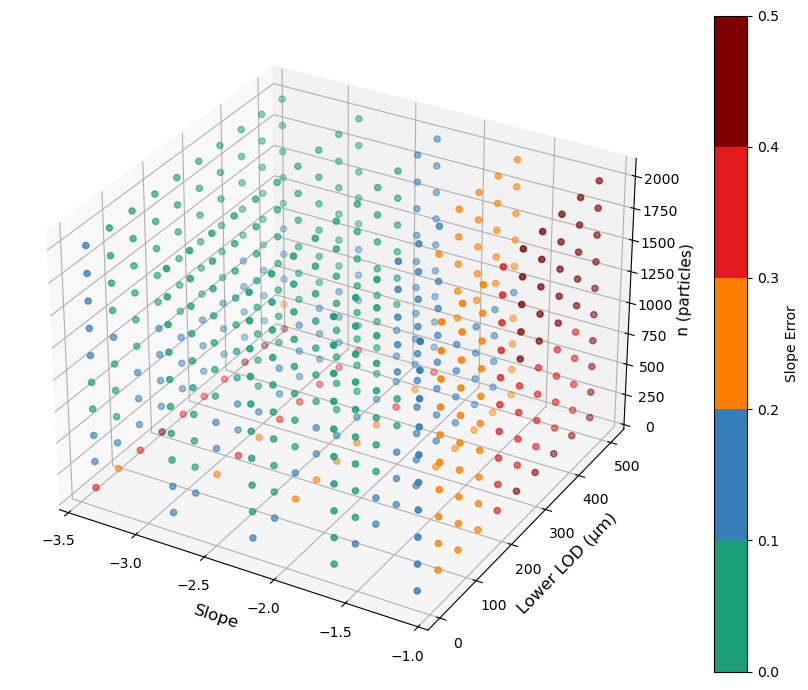

In [19]:
### 3D USING DEFINED COLOR BARS ###

boundaries = [0, 0.1, 0.2, 0.3, 0.4, 0.5]  # You can extend this range if needed
colors = ['#1b9e77', '#377eb8', '#ff7f00', '#e41a1c','#7f0000']  # green, blue, orange, red, dark red

# Color-blind safe palette (ColorBrewer / Okabe-Ito inspired)
cmap = ListedColormap(colors)
norm = BoundaryNorm(boundaries, len(colors))

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    results_df['slope'],
    results_df['LOD'],
    results_df['n'],
    c=results_df['slope_error'],
    cmap=cmap,
    norm=norm
)

ax.set_xlabel('Slope',fontsize=12)
ax.set_ylabel('Lower LOD (µm)',fontsize=12)
ax.set_zlabel('n (particles)',fontsize=11)
ax.set_title('')
fig.colorbar(sc, ax=ax, label='Slope Error')
plt.tight_layout()


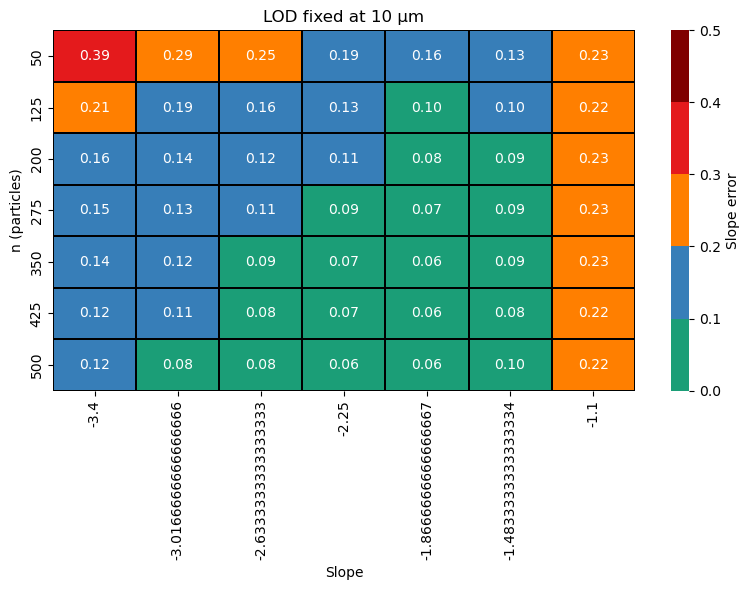

In [13]:

boundaries = [0, 0.1, 0.2, 0.3, 0.4, 0.5]  
colors = ['#1b9e77', '#377eb8', '#ff7f00', '#e41a1c','#7f0000']  

# Color-blind safe palette (ColorBrewer / Okabe-Ito inspired)
cmap = ListedColormap(colors)
norm = BoundaryNorm(boundaries, len(colors))

# Fix the number of particles
LOD_fixed = 10  # or pick another value you want

# Filter the data
df_slice = results_df[results_df['LOD'] == LOD_fixed]

# Optional: sort to ensure consistency in plotting
df_slice = df_slice.sort_values(by=['slope', 'n'])

# Create pivot table to reshape for heatmap
pivot = df_slice.pivot(index='n', columns='slope', values='slope_error')

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    pivot,
    cmap=cmap,
    norm=norm,
    cbar_kws={'label': 'Slope error'},
    linewidths=0.3,
    linecolor='black',

    annot=True,
    fmt=".2f"
)
plt.title(f"LOD fixed at {LOD_fixed} µm")
plt.xlabel("Slope")
plt.ylabel("n (particles)")
plt.tight_layout()
plt.show()


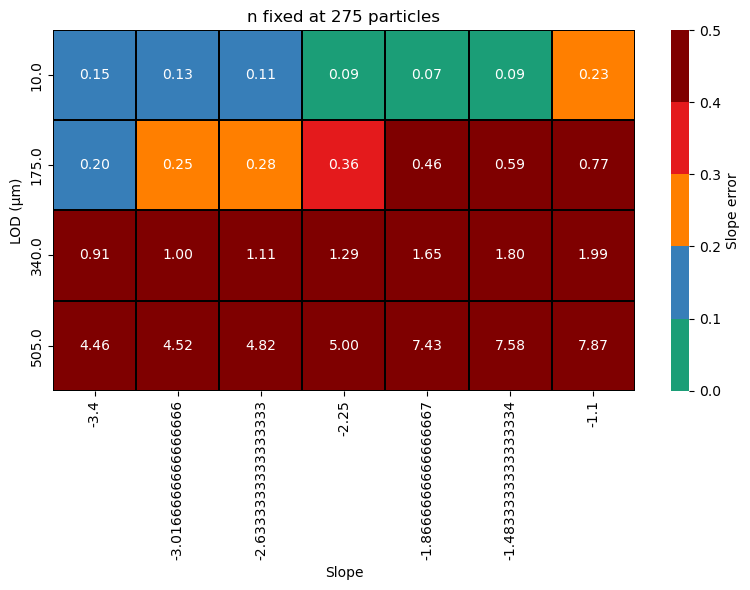

In [14]:
# Fix the number of particles
n_fixed = 275  # or pick another value you want

# Filter the data
df_slice = results_df[results_df['n'] == n_fixed]

# Optional: sort to ensure consistency in plotting
df_slice = df_slice.sort_values(by=['slope', 'LOD'])

# Create pivot table to reshape for heatmap
pivot = df_slice.pivot(index='LOD', columns='slope', values='slope_error')

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    pivot,
    cmap=cmap,
    norm=norm,
    cbar_kws={'label': 'Slope error'},
    linewidths=0.3,
    linecolor='black',

    annot=True,
    fmt=".2f"
)
plt.title(f"n fixed at {n_fixed} particles")
plt.xlabel("Slope")
plt.ylabel("LOD (µm)")
plt.tight_layout()
plt.show()

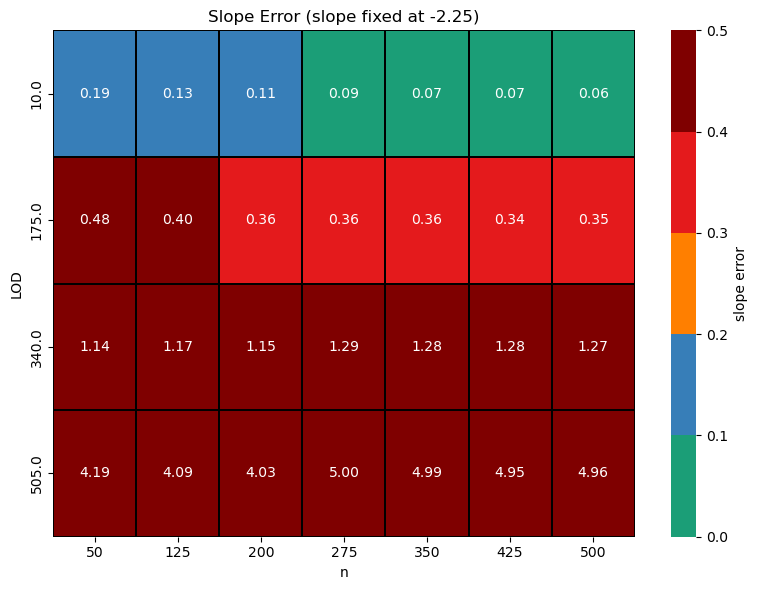

In [15]:
# Fix the number of particles
slope_fixed = -2.25  # or pick another value you want

# Filter the data
df_slice = results_df[results_df['slope'] == slope_fixed]

# Optional: sort to ensure consistency in plotting
df_slice = df_slice.sort_values(by=['n', 'LOD'])

# Create pivot table to reshape for heatmap
pivot = df_slice.pivot(index='LOD', columns='n', values='slope_error')

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    pivot,
    cmap=cmap,
    norm=norm,
    cbar_kws={'label': 'slope error'},
    linewidths=0.3,
    linecolor='black',

    annot=True,
    fmt=".2f"
)
plt.title(f"Slope Error (slope fixed at {slope_fixed})")
plt.xlabel("n")
plt.ylabel("LOD")
plt.tight_layout()
plt.show()

/tmp/ipykernel_492/235970441.py:28: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


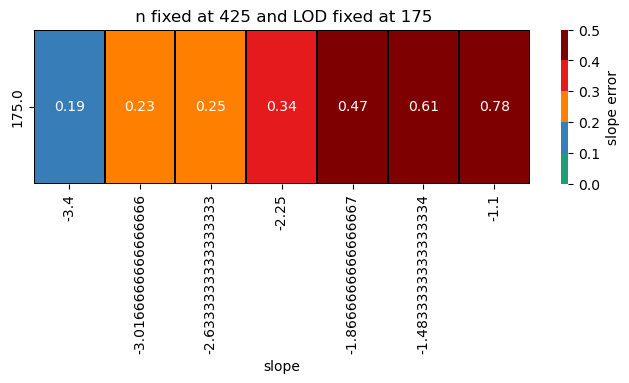

In [20]:
n_fixed = 425 # or pick another value you want
LOD_fixed = 175  # or pick another value you want

# Filter the data
df_slice = results_df[results_df['n'] == n_fixed]

# Optional: sort to ensure consistency in plotting
df_slice = df_slice.sort_values(by=['n', 'LOD'])
df_slice2 = df_slice[df_slice['LOD'] == LOD_fixed]
pivot = df_slice2.pivot(index='LOD', columns='slope', values='slope_error')

plt.figure(figsize=(8, 2))

sns.heatmap(
    pivot,
    cmap=cmap,
    norm=norm,
    cbar_kws={'label': 'slope error'},
    linewidths=0.3,
    linecolor='black',

    annot=True,
    fmt=".2f"
)
plt.title(f" n fixed at {n_fixed} and LOD fixed at {LOD_fixed}")
plt.xlabel("slope")
plt.ylabel("")
plt.tight_layout()
plt.show()